# Lecture 2: What does PM2.5 tell us?

**Question:** How do daily PM2.5 measurements become a defensible comparison of air quality across years?

We will inspect the 2020-2023 files, calculate a provisional PM2.5 sub-index, investigate coverage and seasonal patterns, and export an interactive dashboard for GitHub Pages.

**Route:** question → Python refresher → audit inputs → inspect PM2.5 → derive AQI → test the rules → compare years fairly → inspect seasons → publish a static dashboard.

In [1]:
# Google Colab only: download this lecture's data and helper files, then work inside that folder.
# Running locally? Start Jupyter in the lecture folder and this cell does nothing.
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('requirements.txt'):
    !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/DrFarrukh/teaching.git /content/teaching
    !git -C /content/teaching sparse-checkout set courses/tools-and-tech-in-data-science/lectures/lecture-02
    os.chdir('/content/teaching/courses/tools-and-tech-in-data-science/lectures/lecture-02')
    !pip -q install -r requirements.txt
    print('Working folder:', os.getcwd())

## 1. Define the claim before writing code

PM2.5 is a mass concentration of fine particles, reported here in µg/m³. AQI is a derived index, not a measurement and not a percentage. The conversion depends on the averaging period, concentration breakpoints, and rounding rules.

We use the US EPA PM2.5 breakpoint scheme introduced in 2024, documented in the [May 2026 technical guidance](https://document.airnow.gov/technical-assistance-document-for-the-reporting-of-daily-air-quailty.pdf), pp. 13–15 / PDF pages 18–20. We apply one fixed scheme retrospectively to all years for comparability. Later we compare it with the older table used in Lecture 1.

Explore four questions:
1. Are the values valid and the dates complete?
2. Which conversion rule did we implement?
3. Are the periods being compared equivalent?
4. Can the result and dashboard be rebuilt from the same inputs?

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project = Path.cwd()
raw_folder = project / "data" / "raw"
output = project / "outputs"
output.mkdir(exist_ok=True)
assert raw_folder.exists(), "Launch Jupyter from the Lecture 2 folder"
print("Python:", sys.version.split()[0])
print("Working directory:", project)

Python: 3.12.14
Working directory: .


## 2. A compact Python refresher

### Names, lists, indexing, and the mean

The first three December 2022 values are a useful small example. `=` assigns; `[]` selects; `()` calls a function. A slice excludes its stop. The denominator here is three, not a whole month.

In [3]:
start=7
end=-1

Name = "Farrukh"
x = ['a',55,Name,'b','c','d','e','f','g','h']
elements_in_x = len(x)
print(f"Numbners of elements in x are:{elements_in_x}")
x[start:end]

Numbners of elements in x are:10


['f', 'g']

In [4]:
readings = [35.60, 51.00, 68.90]
# print(readings[-1])
# print(readings[:2])
total = sum(readings)
mean_reading = total / len(readings)
print(total, mean_reading)

155.5 51.833333333333336


### Trace a loop before using a vectorized expression

Indentation identifies the repeated block. We count readings above the sample mean.

In [5]:
count_above = 0
for reading in readings:
    if reading > mean_reading:
        count_above = count_above + 1
print(count_above)

1


### NumPy: elementwise operations and Boolean masks

Multiplying a list repeats it. Multiplying an array scales its entries. A mask contains one Boolean per entry; using the mask selects entries, while summing it counts True values.

In [6]:
values = np.array(readings)
# print(readings)
# print(readings * 2)
# print(values * 2)
mask = values < values.mean()
print(mask)
print(values[mask])
print(mask.sum())

[ True  True False]
[35.6 51. ]
2


In [7]:
values.mean()

np.float64(51.833333333333336)

### A table has named columns and indexed rows

A dictionary maps column names to values. pandas calls the resulting table a DataFrame. One selected column is a Series; a list of column names returns a DataFrame.

In [8]:
example = pd.DataFrame({
    "day": [1, 2, 3],
    "pm25": readings
    })

print(example.shape)
example

(3, 2)


,day,pm25
0,1,35.6
1,2,51.0
2,3,68.9


### Separate the condition from selection

`loc` selects by a Boolean mask and named columns. Writing the mask separately makes the selection inspectable. `iloc` uses positions. We will reuse this pattern for year, month, and AQI bands.

In [9]:
mask = example["pm25"] > 50
print(mask)

example.loc[mask, ["day", "pm25"]]

0    False
1     True
2     True
Name: pm25, dtype: bool


,day,pm25
1,2,51.0
2,3,68.9


### Stored results do not update automatically

Changing the input does not recalculate an earlier scalar. This is why later comparisons must be derived from the current, explicitly selected table, and why we restart/run-all.

In [10]:
demo = [10, 20, 90]

In [11]:
stored_mean = sum(demo) / len(demo)
stored_mean

40.0

In [12]:
print("Stored:", stored_mean)
print("Recalculated:", sum(demo) / len(demo))

Stored: 40.0
Recalculated: 40.0


## 3. Audit two files before combining them
The files are existing course data, not newly downloaded observations. Read them as text first so original cell values remain available for conversion checks. A filename ending in “23” does not establish a full year of coverage.

### Open the two snapshots

Inspect the head and tail separately. The 2023 file contains trailing blank records; they must be counted and documented before removal.

In [13]:
older = pd.read_csv(raw_folder / "AQI-Data-20-22.csv", dtype="string")
newer = pd.read_csv(raw_folder / "AQI-Data-23.csv", dtype="string")
print("2020-22 file:", older.shape)
print("2023 file:", newer.shape)
# newer.head(2)
newer.tail(50)

2020-22 file: (1095, 6)
2023 file: (99, 6)


,Date,Temperature,Humidity,NO2,SO2,PM2.5
49,19/02/2023,14.33,63,6.73,27.3,60
50,20/02/2023,15,54,6.88,25.9,71
51,21/02/2023,15.7,43.33,6.7,19.2,20.66
52,22/02/2023,15.33,46,6.2,20.1,18
53,23/02/2023,15,47,6.5,21.46,22.7
54,24/02/2023,15.66,51,5.8,23.8,41.33
55,25/02/2023,15.66,56,5.6,21.9,26
56,26/02/2023,16,49.33,5.43,19.96,18.33
57,27/02/2023,15,51,5.22,19.51,23
58,28/02/2023,14.66,55.7,5.14,19.2,21


### Count empty records before adding provenance columns

If we add a nonempty filename column first, `.isna().all(axis=1)` would no longer identify empty measurement rows. Ordering changes the meaning of this check.

In [14]:
older_blank = older.isna().all(axis=1)

newer_blank = newer.isna().all(axis=1)

blank_audit = pd.DataFrame({
    "file": ["AQI-Data-20-22.csv", "AQI-Data-23.csv"],
    "raw_rows": [len(older), len(newer)],
    "blank_rows": [older_blank.sum(), newer_blank.sum()]
})
blank_audit
# newer_blank

,file,raw_rows,blank_rows
0,AQI-Data-20-22.csv,1095,0
1,AQI-Data-23.csv,99,40


### Preserve physical source rows

CSV line 1 is the header, so the first data record is source row 2. Filtering retains the original index until we concatenate. That lets a derived value be traced to its source record.

In [15]:
older = older.loc[~older_blank].copy()
newer = newer.loc[~newer_blank].copy()
older["source_file"] = "AQI-Data-20-22.csv"
newer["source_file"] = "AQI-Data-23.csv"
older["source_row"] = older.index + 2
newer["source_row"] = newer.index + 2
data = pd.concat([older, newer], ignore_index=True)
print(data.shape)
data.head()

(1154, 8)


,Date,Temperature,Humidity,NO2,SO2,PM2.5,source_file,source_row
0,01/01/2020,7.6,68.52,33.63,42.93,38.17,AQI-Data-20-22.csv,2
1,02/01/2020,7.52,72.25,35.64,45.34,49.6,AQI-Data-20-22.csv,3
2,03/01/2020,6.5,74.12,34.42,44.4,44.93,AQI-Data-20-22.csv,4
3,04/01/2020,7.01,65.1,31.2,37.6,51.35,AQI-Data-20-22.csv,5
4,05/01/2020,6.58,68.4,30.5,48.6,65.4,AQI-Data-20-22.csv,6


### Parse dates explicitly; preserve the original text

`%d/%m/%Y` records day-first interpretation. `errors="coerce"` makes bad parses visible as missing; it does not authorize silently discarding them.

In [16]:
data["date_text"] = data["Date"]
data["Date"] = pd.to_datetime(data["date_text"], format="%d/%m/%Y", errors="coerce")

date_issues = data.loc[data["Date"].isna(), ["date_text", "source_file", "source_row"]]

print("Invalid dates:", len(date_issues))
assert date_issues.empty
data = data.sort_values("Date").reset_index(drop=True)

Invalid dates: 0


In [17]:
data

,Date,Temperature,Humidity,NO2,SO2,PM2.5,source_file,source_row,date_text
0,2020-01-01,7.6,68.52,33.63,42.93,38.17,AQI-Data-20-22.csv,2,01/01/2020
1,2020-01-02,7.52,72.25,35.64,45.34,49.6,AQI-Data-20-22.csv,3,02/01/2020
2,2020-01-03,6.5,74.12,34.42,44.4,44.93,AQI-Data-20-22.csv,4,03/01/2020
3,2020-01-04,7.01,65.1,31.2,37.6,51.35,AQI-Data-20-22.csv,5,04/01/2020
4,2020-01-05,6.58,68.4,30.5,48.6,65.4,AQI-Data-20-22.csv,6,05/01/2020
...,...,...,...,...,...,...,...,...,...
1149,2023-02-24,15.66,51,5.8,23.8,41.33,AQI-Data-23.csv,56,24/02/2023
1150,2023-02-25,15.66,56,5.6,21.9,26,AQI-Data-23.csv,57,25/02/2023
1151,2023-02-26,16,49.33,5.43,19.96,18.33,AQI-Data-23.csv,58,26/02/2023
1152,2023-02-27,15,51,5.22,19.51,23,AQI-Data-23.csv,59,27/02/2023


### Convert measurements without losing evidence

Keep the raw PM2.5 string because decimal truncation will matter later. The simple loop repeats the same conversion for five columns. Missing or invalid PM2.5 prevents the subsequent calculation in this teaching dataset.

In [18]:
data["pm25_text"] = data["PM2.5"]

measurements = ["Temperature", "Humidity", "NO2", "SO2", "PM2.5"]

for column in measurements:
    data[column] = pd.to_numeric(data[column], errors="coerce")
print(data[measurements].isna().sum())

assert data["PM2.5"].notna().all()
assert np.isfinite(data["PM2.5"]).all()
assert data["PM2.5"].ge(0).all()
assert data["Date"].is_unique

Temperature    0
Humidity       0
NO2            0
SO2            0
PM2.5          0
dtype: int64


### A calendar reveals omissions that row counts hide

We compare against every calendar day from the first through last observed date. Do not fill absent measurements with zero. The missing date is **October 31, 2020**, not February 29.

In [19]:
print(data["Date"].min())
print(data["Date"].max())

temp = pd.date_range(data["Date"].min(), data["Date"].max(), freq="h")
len(temp)
# D = Daily
# MS = Month Start
# YE = Year End

2020-01-01 00:00:00
2023-02-28 00:00:00


27697

In [20]:
calendar = pd.date_range(data["Date"].min(), data["Date"].max(), freq="D")

missing_dates = calendar.difference(data["Date"])

print("Observed span:", data["Date"].min(), "to", data["Date"].max())
print("Missing calendar days:", missing_dates.tolist())
data["year"] = data["Date"].dt.year
data["month"] = data["Date"].dt.month
data.groupby("year")["Date"].agg(["count", "min", "max"])

Observed span: 2020-01-01 00:00:00 to 2023-02-28 00:00:00
Missing calendar days: [Timestamp('2020-10-31 00:00:00')]


,count,min,max
year,,,
2020,365,2020-01-01,2020-12-31
2021,365,2021-01-01,2021-12-31
2022,365,2022-01-01,2022-12-31
2023,59,2023-01-01,2023-02-28


| Method            | Converts to       |
| ----------------- | ----------------- |
| `.tolist()`       | Python list       |
| `.to_numpy()`     | NumPy array       |
| `.to_frame()`     | DataFrame         |
| `.to_dict()`      | Python dictionary |
| `.to_csv()`       | CSV file/string   |
| `.to_excel()`     | Excel file        |
| `.to_json()`      | JSON              |
| `.to_string()`    | printable string  |
| `.to_clipboard()` | clipboard         |


### Measure full-year coverage

2020 is a leap year: 365 records do not imply complete coverage. 2023 contains January–February only. Expected calendar days and observed rows answer different questions.

In [21]:
coverage = data.groupby("year").agg(
    observed_days=("Date", "size"), first_day=("Date", "min"), last_day=("Date", "max")
)
year_start = pd.to_datetime(coverage.index.astype(str) + "-01-01")
coverage["expected_days"] = np.where(year_start.is_leap_year, 366, 365)
coverage["coverage_pct"] = 100 * coverage["observed_days"] / coverage["expected_days"]
coverage

,observed_days,first_day,last_day,expected_days,coverage_pct
year,,,,,
2020,365,2020-01-01,2020-12-31,366,99.726776
2021,365,2021-01-01,2021-12-31,365,100.000000
2022,365,2022-01-01,2022-12-31,365,100.000000
2023,59,2023-01-01,2023-02-28,365,16.164384


## 4. What does PM2.5 itself say?
Inspect concentration before converting it. A high annual mean can arise from persistent moderate values or a few large episodes. Summary statistics describe the supplied monitoring series, not all residents or all locations in Islamabad.

### Yearly concentration summaries

`groupby` partitions rows by year, then applies each statistic within a partition. The partial 2023 period makes an immediate annual ranking misleading.

In [22]:
data

,Date,Temperature,Humidity,NO2,SO2,PM2.5,source_file,source_row,date_text,pm25_text,year,month
0,2020-01-01,7.6,68.52,33.63,42.93,38.17,AQI-Data-20-22.csv,2,01/01/2020,38.17,2020,1
1,2020-01-02,7.52,72.25,35.64,45.34,49.6,AQI-Data-20-22.csv,3,02/01/2020,49.6,2020,1
2,2020-01-03,6.5,74.12,34.42,44.4,44.93,AQI-Data-20-22.csv,4,03/01/2020,44.93,2020,1
3,2020-01-04,7.01,65.1,31.2,37.6,51.35,AQI-Data-20-22.csv,5,04/01/2020,51.35,2020,1
4,2020-01-05,6.58,68.4,30.5,48.6,65.4,AQI-Data-20-22.csv,6,05/01/2020,65.4,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2023-02-24,15.66,51.0,5.8,23.8,41.33,AQI-Data-23.csv,56,24/02/2023,41.33,2023,2
1150,2023-02-25,15.66,56.0,5.6,21.9,26.0,AQI-Data-23.csv,57,25/02/2023,26,2023,2
1151,2023-02-26,16.0,49.33,5.43,19.96,18.33,AQI-Data-23.csv,58,26/02/2023,18.33,2023,2
1152,2023-02-27,15.0,51.0,5.22,19.51,23.0,AQI-Data-23.csv,59,27/02/2023,23,2023,2


In [23]:
data.groupby("year")["SO2"].count()

# .mean()
# .sum()
# .min()
# .max()
# .count()
# .size()
# .agg(...)

year
2020    365
2021    365
2022    365
2023     59
Name: SO2, dtype: Int64

In [24]:
data.groupby("year")["PM2.5"].agg(["mean","max","min"])

,mean,max,min
year,,,
2020,31.948384,103.04,5.46
2021,35.416466,198.96,5.6
2022,33.988082,145.76,4.66
2023,50.473051,112.0,16.56


In [25]:
# data.groupby("year")["PM2.5"].max()

data.groupby("year")["PM2.5"].idxmax()

idx = data.groupby("year")["PM2.5"].idxmax()
data.loc[idx, ["year", "Date", "PM2.5"]]

,year,Date,PM2.5
40,2020,2020-02-10,103.04
719,2021,2021-12-21,198.96
746,2022,2022-01-17,145.76
1097,2023,2023-01-03,112.0


In [26]:
# data.groupby("month")["PM2.5"].agg(["count", "mean", "median", "min", "max"])
# data

In [27]:
data.groupby("month")[["PM2.5","SO2"]].max()

,PM2.5,SO2
month,,
1,145.76,78.88
2,103.04,48.6
3,73.4,37.73
4,36.8,30.1
5,39.33,26.8
6,49.33,24.1
7,40.88,39.4
8,41.6,36.7
9,43.2,38.7


In [28]:
idx = data.groupby("year")[["PM2.5", "SO2"]].idxmax()

data.loc[idx["PM2.5"], ["year", "Date", "PM2.5"]]
data.loc[idx["SO2"], ["year", "Date", "SO2"]]

,year,Date,SO2
7,2020,2020-01-08,78.88
701,2021,2021-12-03,55.94
1088,2022,2022-12-25,39.7
1099,2023,2023-01-05,58.23


In [29]:
summary = pd.DataFrame({
    "PM2.5_max": data.loc[idx["PM2.5"], "PM2.5"].values,
    "PM2.5_date": data.loc[idx["PM2.5"], "Date"].values,
    "SO2_max": data.loc[idx["SO2"], "SO2"].values,
    "SO2_date": data.loc[idx["SO2"], "Date"].values
}, index=idx.index)

summary

,PM2.5_max,PM2.5_date,SO2_max,SO2_date
year,,,,
2020,103.04,2020-02-10,78.88,2020-01-08
2021,198.96,2021-12-21,55.94,2021-12-03
2022,145.76,2022-01-17,39.7,2022-12-25
2023,112.0,2023-01-03,58.23,2023-01-05


In [30]:
pm_summary = data.groupby("year")["PM2.5"].agg(["count", "mean", "median", "min", "max"])
pm_summary.round(2)

,count,mean,median,min,max
year,,,,,
2020,365,31.95,27.62,5.46,103.04
2021,365,35.42,23.61,5.6,198.96
2022,365,33.99,25.44,4.66,145.76
2023,59,50.47,45.5,16.56,112.0


### Find the actual high-concentration records

`nlargest` selects records, not just the largest numeric value. Keeping source identifiers means a suspicious peak can be checked against the original working file.

In [31]:
data.nlargest(8, "PM2.5")[["Date", "PM2.5", "source_file", "source_row"]]

,Date,PM2.5,source_file,source_row
719,2021-12-21,198.96,AQI-Data-20-22.csv,721
720,2021-12-22,182.1,AQI-Data-20-22.csv,722
721,2021-12-23,156.53,AQI-Data-20-22.csv,723
718,2021-12-20,156.2,AQI-Data-20-22.csv,720
717,2021-12-19,149.4,AQI-Data-20-22.csv,719
746,2022-01-17,145.76,AQI-Data-20-22.csv,748
723,2021-12-25,142.8,AQI-Data-20-22.csv,725
701,2021-12-03,133.97,AQI-Data-20-22.csv,703


### Plot concentration on a complete calendar

`reindex` inserts a missing entry for an absent date. Matplotlib then breaks the line instead of silently connecting observations across that missing day.

In [32]:
daily = data.set_index("Date").reindex(calendar)
daily

,Temperature,Humidity,NO2,SO2,PM2.5,source_file,source_row,date_text,pm25_text,year,month
2020-01-01,7.6,68.52,33.63,42.93,38.17,AQI-Data-20-22.csv,2.0,01/01/2020,38.17,2020.0,1.0
2020-01-02,7.52,72.25,35.64,45.34,49.6,AQI-Data-20-22.csv,3.0,02/01/2020,49.6,2020.0,1.0
2020-01-03,6.5,74.12,34.42,44.4,44.93,AQI-Data-20-22.csv,4.0,03/01/2020,44.93,2020.0,1.0
2020-01-04,7.01,65.1,31.2,37.6,51.35,AQI-Data-20-22.csv,5.0,04/01/2020,51.35,2020.0,1.0
2020-01-05,6.58,68.4,30.5,48.6,65.4,AQI-Data-20-22.csv,6.0,05/01/2020,65.4,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2023-02-24,15.66,51.0,5.8,23.8,41.33,AQI-Data-23.csv,56.0,24/02/2023,41.33,2023.0,2.0
2023-02-25,15.66,56.0,5.6,21.9,26.0,AQI-Data-23.csv,57.0,25/02/2023,26,2023.0,2.0
2023-02-26,16.0,49.33,5.43,19.96,18.33,AQI-Data-23.csv,58.0,26/02/2023,18.33,2023.0,2.0
2023-02-27,15.0,51.0,5.22,19.51,23.0,AQI-Data-23.csv,59.0,27/02/2023,23,2023.0,2.0


In [33]:
xticks = pd.date_range(
    daily.index.min(),
    daily.index.max(),
    freq="MS"
)
xtick_labels = xticks.strftime("%b-%Y")
xtick_labels

Index(['Jan-2020', 'Feb-2020', 'Mar-2020', 'Apr-2020', 'May-2020', 'Jun-2020',
       'Jul-2020', 'Aug-2020', 'Sep-2020', 'Oct-2020', 'Nov-2020', 'Dec-2020',
       'Jan-2021', 'Feb-2021', 'Mar-2021', 'Apr-2021', 'May-2021', 'Jun-2021',
       'Jul-2021', 'Aug-2021', 'Sep-2021', 'Oct-2021', 'Nov-2021', 'Dec-2021',
       'Jan-2022', 'Feb-2022', 'Mar-2022', 'Apr-2022', 'May-2022', 'Jun-2022',
       'Jul-2022', 'Aug-2022', 'Sep-2022', 'Oct-2022', 'Nov-2022', 'Dec-2022',
       'Jan-2023', 'Feb-2023'],
      dtype='str')

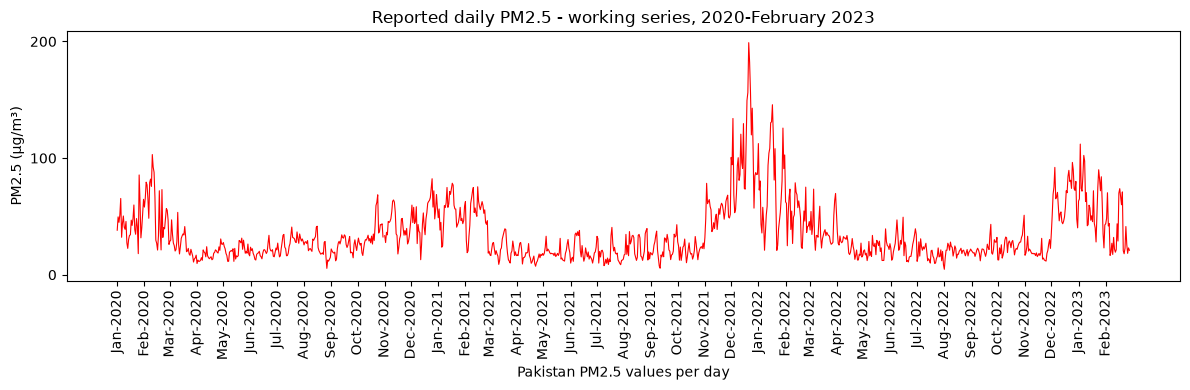

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily["PM2.5"],
        linewidth=0.8, 
        color="red"
        )
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Pakistan PM2.5 values per day")
plt.title("Reported daily PM2.5 - working series, 2020-February 2023")
plt.xticks(rotation=90, ticks=xticks, labels=xtick_labels)
plt.yticks(ticks=np.arange(0, 300, 100))
plt.tight_layout()
# plt.savefig(output / "01_pm25_daily.pdf", dpi=300)
plt.show()

### Smooth only after defining calendar time

A seven-row window is seven days only after daily reindexing. `min_periods=7` requires seven available readings; windows crossing the missing day remain missing. The smooth line is descriptive, not a forecast.

In [35]:
daily["pm25_7day"] = daily["PM2.5"].rolling(7, min_periods=7).mean()
daily["pm25_7day"]

2020-01-01          NaN
2020-01-02          NaN
2020-01-03          NaN
2020-01-04          NaN
2020-01-05          NaN
                ...    
2023-02-24    42.927143
2023-02-25    37.098571
2023-02-26    31.145714
2023-02-27    24.288571
2023-02-28    24.337143
Freq: D, Name: pm25_7day, Length: 1155, dtype: float64

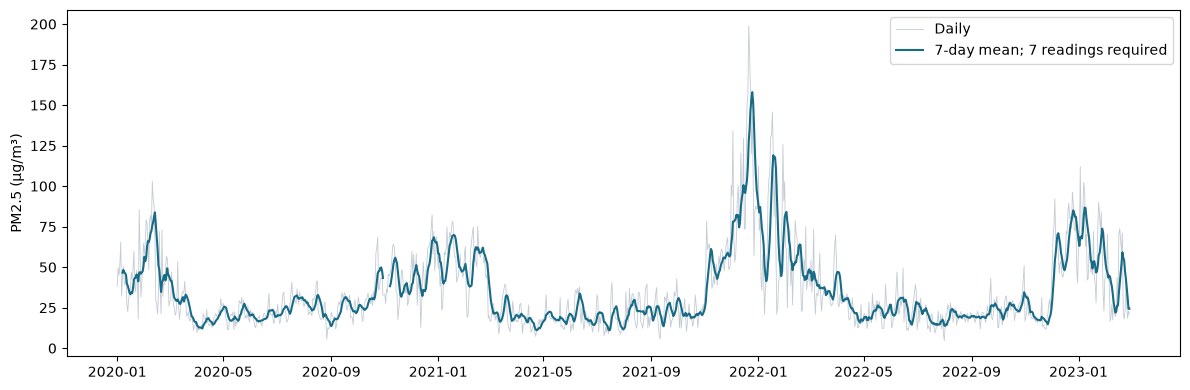

In [36]:
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily["PM2.5"], color="#c3cbd3", linewidth=0.6, label="Daily")
plt.plot(daily.index, daily["pm25_7day"], color="#176b87", label="7-day mean; 7 readings required")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig(output / "02_pm25_rolling.pdf", dpi=600)
plt.show()

## 5. Build AQI from a single concentration
The rules require a 24-hour PM2.5 concentration, truncated to one decimal place. Find its concentration interval, linearly interpolate into the index interval, then round the index to an integer. We use explicit half-up rounding for nonnegative indices, consistent with the worked rounding example in the guidance.

Within an interval:
$$I=\frac{I_H-I_L}{C_H-C_L}(C-C_L)+I_L.$$

The slope converts concentration units into index units. Breakpoint changes alter the slope. AQI is therefore piecewise linear, not one multiplier for every concentration.

The fixed 2024 PM2.5 scheme below is from [EPA Table 6](https://document.airnow.gov/technical-assistance-document-for-the-reporting-of-daily-air-quailty.pdf). We represent its range through index 500; inputs above this implementation's range are flagged, not silently clipped. All actual values in our files are within range.

### Store the rule as data

Each row is one concentration interval and its matching AQI interval. The table is configuration that must travel with the code. It is not a set of observations.

In [37]:
breakpoints = pd.DataFrame([
    [0.0, 9.0, 0, 50],
    [9.1, 35.4, 51, 100],
    [35.5, 55.4, 101, 150],
    [55.5, 125.4, 151, 200],
    [125.5, 225.4, 201, 300],
    [225.5, 325.4, 301, 500]
], columns=["c_low", "c_high", "i_low", "i_high"])
scheme = "US_EPA_PM25_2024_fixed_retrospective"
breakpoints

,c_low,c_high,i_low,i_high
0,0.0,9.0,0,50
1,9.1,35.4,51,100
2,35.5,55.4,101,150
3,55.5,125.4,151,200
4,125.5,225.4,201,300
5,225.5,325.4,301,500


### Truncation is not rounding

`Decimal` uses the displayed decimal string so binary floating-point representation does not accidentally move a breakpoint input downward. For nonnegative concentrations, ROUND_DOWN implements truncation toward zero.

In [38]:
from decimal import Decimal, InvalidOperation, ROUND_DOWN, ROUND_HALF_UP

raw_value = "35.49"
concentration = Decimal(raw_value).quantize(Decimal("0.1"), rounding=ROUND_DOWN)
print("Original:", raw_value)
print("Truncated:", concentration)
print("Rounded instead:", Decimal(raw_value).quantize(Decimal("0.1"), rounding=ROUND_HALF_UP))

Original: 35.49
Truncated: 35.4
Rounded instead: 35.5


### Find the interval explicitly

Use the same Boolean-selection pattern as before. Truncating 35.49 gives 35.4, so it belongs to the interval ending at 35.4. Rounding it first would cross a category boundary.

In [39]:
c = float(concentration)
inside = (breakpoints["c_low"] <= c) & (c <= breakpoints["c_high"])
matching = breakpoints.loc[inside]
assert len(matching) == 1
matching

,c_low,c_high,i_low,i_high
1,9.1,35.4,51,100


### Work one interpolation by hand and in code

Use 35.9 µg/m³, inside 35.5–55.4. Substitute each quantity before simplifying. The unrounded index is about 101.985; the integer result is 102.

In [40]:
c = 35.9
c_low, c_high = 35.5, 55.4
i_low, i_high = 101, 150
slope = (i_high - i_low) / (c_high - c_low)
unrounded_index = slope * (c - c_low) + i_low
print("Slope:", slope)
print("Unrounded index:", unrounded_index)
print("Rounded:", Decimal(str(unrounded_index)).quantize(Decimal("1"), rounding=ROUND_HALF_UP))

Slope: 2.462311557788945
Unrounded index: 101.98492462311557
Rounded: 102


### Compare final rounding rules

Lecture 1 used floor on the final index, systematically rounding fractional values downward. Python round uses ties-to-even. We specify the intended policy instead of inheriting an accidental language default.

In [41]:
print("Floor:", np.floor(101.985))
print("Python round at an exact half:", round(102.5))
print("Half-up at the same half:", Decimal("102.5").quantize(Decimal("1"), rounding=ROUND_HALF_UP))

Floor: 101.0
Python round at an exact half: 102
Half-up at the same half: 103


### Package only the steps we have already explained
This is the **one custom function** in the lecture. `value` and `table` are explicit inputs. It returns an integer index, or missing for missing/invalid/out-of-range input. It neither changes the source table nor accesses hidden notebook variables.

Read the function in four blocks: validate → truncate → find interval → interpolate/round. `try` attempts decimal conversion; `except InvalidOperation` catches nonnumeric text and returns missing. `itertuples` visits breakpoint rows and makes each column available as an attribute. `return` stops the function once the interval matches. The final return is reached only if no interval matches.

Reject negative values **before** truncation; otherwise a small negative input could become zero. This teaching implementation stops at the last tabulated endpoint; it does not implement extrapolation beyond index 500.

In [42]:
def pm25_to_aqi(value, table):
    if pd.isna(value):
        return np.nan
    try:
        original = Decimal(str(value))
    except InvalidOperation:
        return np.nan
    if not original.is_finite() or original < 0:
        return np.nan
    c = original.quantize(Decimal("0.1"), rounding=ROUND_DOWN)
    for row in table.itertuples(index=False):
        low = Decimal(str(row.c_low))
        high = Decimal(str(row.c_high))
        if low <= c <= high:
            index_low = Decimal(str(row.i_low))
            index_high = Decimal(str(row.i_high))
            slope = (index_high - index_low) / (high - low)
            index = slope * (c - low) + index_low
            return int(index.quantize(Decimal("1"), rounding=ROUND_HALF_UP))
    return np.nan

### Test boundaries, not only a typical example

Expected outputs are stated independently from the implementation. Include both sides of boundaries, an EPA worked example, missing data, a negative value, and a value outside our supported range.

In [43]:
test_values = [0, 9.0, 9.09, 9.1, 35.49, 35.5, 35.9, 55.4, 55.5, 125.4, 125.5, 225.4, 225.5, 325.4]
expected = [0, 50, 50, 51, 100, 101, 102, 150, 151, 200, 201, 300, 301, 500]
actual = []
for value in test_values:
    actual.append(pm25_to_aqi(value, breakpoints))
assert actual == expected
assert pd.isna(pm25_to_aqi(np.nan, breakpoints))
assert pd.isna(pm25_to_aqi(-0.01, breakpoints))
assert pd.isna(pm25_to_aqi("bad text", breakpoints))
assert pd.isna(pm25_to_aqi(400, breakpoints))
pd.DataFrame({"PM2.5": test_values, "expected": expected, "actual": actual})

,PM2.5,expected,actual
0,0.00,0,0
1,9.00,50,50
2,9.09,50,50
3,9.10,51,51
4,35.49,100,100
5,35.50,101,101
6,35.90,102,102
7,55.40,150,150
8,55.50,151,151
9,125.40,200,200


### Apply the tested rule to every observation

Use a plain loop first so inputs and outputs are visible. We pass the preserved decimal strings, not a concentration rounded earlier for display. The result is a new column; measurements stay unchanged.

In [44]:
aqi_values = []
for value in data["pm25_text"]:
    aqi_values.append(pm25_to_aqi(value, breakpoints))
data["aqi"] = pd.Series(aqi_values, dtype="Int64")
assert data["aqi"].notna().all(), "Inspect invalid or unsupported concentrations"
data["aqi_scheme"] = scheme
data[["Date", "PM2.5", "aqi", "aqi_scheme"]].head()

,Date,PM2.5,aqi,aqi_scheme
0,2020-01-01,38.17,107,US_EPA_PM25_2024_fixed_retrospective
1,2020-01-02,49.6,136,US_EPA_PM25_2024_fixed_retrospective
2,2020-01-03,44.93,124,US_EPA_PM25_2024_fixed_retrospective
3,2020-01-04,51.35,140,US_EPA_PM25_2024_fixed_retrospective
4,2020-01-05,65.4,158,US_EPA_PM25_2024_fixed_retrospective


## Break
After the break: categories, rule-version sensitivity, fair annual comparisons, seasonal aggregation, and the dashboard. No student exercise is being used to fill this interval.

## 6. What changes when the rule changes?
A reproducible result includes its rule table and rounding policy. Applying a newer scheme to older data can support a fixed-rule comparison, but it does not reconstruct the index officially reported at the time.

### Give the integer index an ordered category

`pd.cut` assigns values to intervals. These right-closed intervals give 50 to Good and 51 to Moderate. Category order matters when plotting: alphabetical order would be misleading.

In [45]:
category_names = ["Good", "Moderate", "Unhealthy for sensitive groups", "Unhealthy", "Very unhealthy", "Hazardous"]
category_edges = [-1, 50, 100, 150, 200, 300, 500]
category_colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"]
data["category"] = pd.cut(data["aqi"], bins=category_edges, labels=category_names)
data["category"].value_counts(sort=False)

category
Good                               10
Moderate                          774
Unhealthy for sensitive groups    176
Unhealthy                         182
Very unhealthy                     12
Hazardous                           0
Name: count, dtype: int64

### Inspect the conversion curve

Calculate the index for a concentration grid. Different slopes make a single straight-line conversion incorrect. The curve also helps explain why transforming an average differs from averaging transformed values.

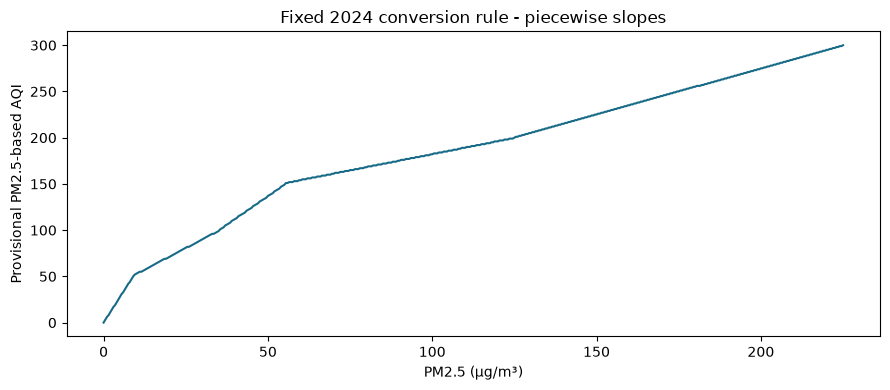

In [46]:
grid = np.linspace(0, 225, 451)
grid_aqi = []
for value in grid:
    grid_aqi.append(pm25_to_aqi(value, breakpoints))
plt.figure(figsize=(9, 4))
plt.plot(grid, grid_aqi, color="#176b87")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Provisional PM2.5-based AQI")
plt.title("Fixed 2024 conversion rule - piecewise slopes")
plt.tight_layout()
plt.savefig(output / "03_conversion_curve.png", dpi=140)
plt.show()

### Recreate the older rule as explicit configuration
The [older EPA Table 5](https://nepis.epa.gov/Exe/ZyPURL.cgi?Dockey=P100W5UG.txt) used different concentration intervals. This was the table used in Lecture 1. Here we change only the table while keeping correct nearest-integer rounding, so the experiment isolates **breakpoint-version effects**. A separate demonstration above isolated the final-rounding issue. We are not editing Lecture 1's historical files.

In [47]:
legacy_breakpoints = pd.DataFrame([
    [0.0, 12.0, 0, 50], [12.1, 35.4, 51, 100],
    [35.5, 55.4, 101, 150], [55.5, 150.4, 151, 200],
    [150.5, 250.4, 201, 300], [250.5, 350.4, 301, 400],
    [350.5, 500.4, 401, 500]
], columns=breakpoints.columns)
legacy_values = []
for value in data["pm25_text"]:
    legacy_values.append(pm25_to_aqi(value, legacy_breakpoints))
data["aqi_legacy"] = legacy_values
data["rule_difference"] = data["aqi"] - data["aqi_legacy"]
data.groupby("year")[["aqi", "aqi_legacy", "rule_difference"]].mean().round(2)

,aqi,aqi_legacy,rule_difference
year,,,
2020,94.36,91.95,2.4
2021,97.79,93.94,3.84
2022,95.81,92.66,3.15
2023,125.92,123.47,2.44


### Did labels change even though measurements did not?

A changed category is a methodological change here, not evidence that the air changed. Keep both the measurement and rule version when reporting derived indicators.

In [48]:
data["legacy_category"] = pd.cut(data["aqi_legacy"], bins=category_edges, labels=category_names)
changed = data["category"] != data["legacy_category"]
print("Days with a changed category:", changed.sum())
data.loc[changed, ["Date", "PM2.5", "aqi_legacy", "aqi", "legacy_category", "category"]].head(8)

Days with a changed category: 47


,Date,PM2.5,aqi_legacy,aqi,legacy_category,category
87,2020-03-28,10.9,45,54,Good,Moderate
91,2020-04-01,9.63,40,52,Good,Moderate
93,2020-04-03,11.43,48,55,Good,Moderate
94,2020-04-04,11.61,48,56,Good,Moderate
126,2020-05-06,11.47,48,55,Good,Moderate
127,2020-05-07,11.52,48,55,Good,Moderate
133,2020-05-13,11.47,48,55,Good,Moderate
241,2020-08-29,11.7,49,56,Good,Moderate


## 7. Compare years without changing the question
We distinguish a mean of observed daily indices from an official annual AQI. Means, medians, high-index days, and coverage describe different aspects of this series. A category attached to a daily index should not be casually assigned to an annual mean.

### Aggregate daily AQI and keep the denominator

Named aggregation makes each output column explicit. The coverage table makes clear that 2023 is partial; 2020 spans a full year but has one missing date.

In [49]:
data["above_100"] = data["aqi"] > 100
annual = data.groupby("year").agg(
    observed_days=("aqi", "count"), mean_aqi=("aqi", "mean"),
    median_aqi=("aqi", "median"), maximum_aqi=("aqi", "max"),
    days_above_100=("above_100", "sum")
)
annual["pct_observed_above_100"] = 100 * annual["days_above_100"] / annual["observed_days"]
annual["coverage_pct"] = coverage["coverage_pct"]
annual.round(2)

,observed_days,mean_aqi,median_aqi,maximum_aqi,days_above_100,pct_observed_above_100,coverage_pct
year,,,,,,,
2020,365,94.36,85.0,184,103,28.22,99.73
2021,365,97.79,78.0,274,123,33.7,100.00
2022,365,95.81,81.0,221,104,28.49,100.00
2023,59,125.92,126.0,191,40,67.8,16.16


### Show the tempting but unequal comparison

Plot it to expose the problem, not to endorse the ranking. January–February is compared with other years’ full seasonal cycles. Grey identifies the incomplete year.

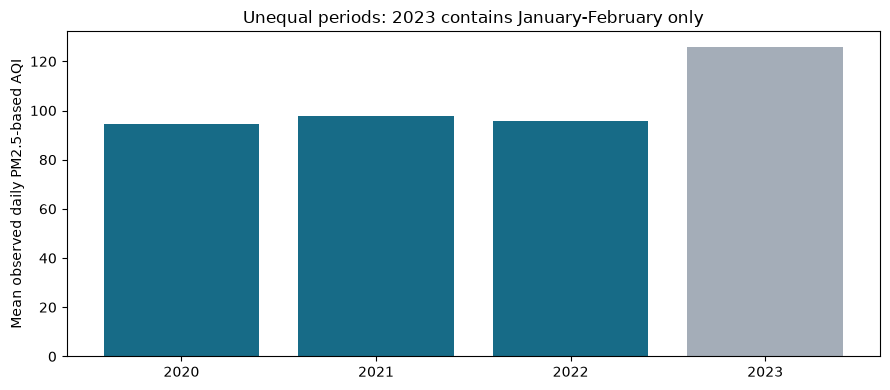

In [50]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(annual.index.astype(str), annual["mean_aqi"], color=["#176b87", "#176b87", "#176b87", "#a4adb8"])
ax.set_ylabel("Mean observed daily PM2.5-based AQI")
ax.set_title("Unequal periods: 2023 contains January-February only")
plt.tight_layout()
plt.savefig(output / "04_unequal_years.png", dpi=140)
plt.show()

### Define a comparable window

Compare January 1–February 28 in every year. Exclude February 29 from 2020 so all windows contain the same 59 calendar days. This answers a narrower question; it is not an annual trend estimate.

In [51]:
jan_feb_mask = data["month"].isin([1, 2])
leap_day = (data["month"] == 2) & (data["Date"].dt.day == 29)
matched = data.loc[jan_feb_mask & ~leap_day].copy()
matched_summary = matched.groupby("year").agg(
    days=("aqi", "count"), mean_aqi=("aqi", "mean"),
    median_aqi=("aqi", "median"), days_above_100=("above_100", "sum")
)
assert matched_summary["days"].eq(59).all()
matched_summary.round(2)

,days,mean_aqi,median_aqi,days_above_100
year,,,,
2020,59,128.27,129.0,44
2021,59,136.0,151.0,51
2022,59,144.51,152.0,51
2023,59,125.92,126.0,40


### Place unequal and matched comparisons side by side

Changing the comparison window can change the apparent ordering. The restriction controls calendar coverage, not station changes, confounding, or source accuracy.

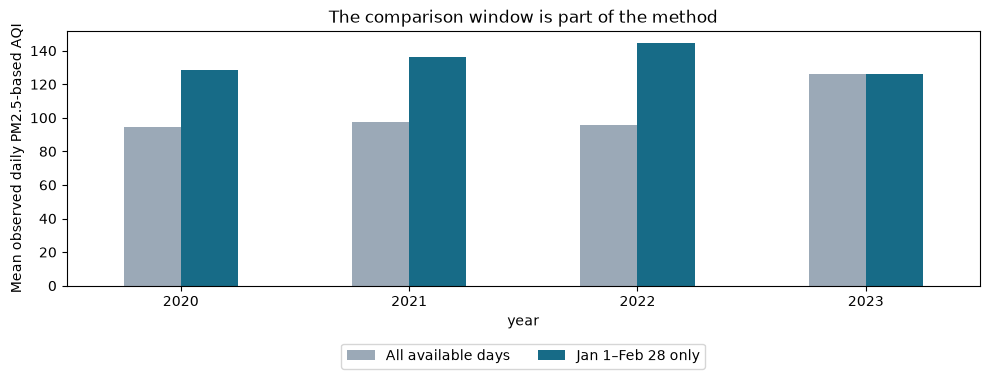

In [52]:
comparison = pd.DataFrame({
    "All available days": annual["mean_aqi"],
    "Jan 1–Feb 28 only": matched_summary["mean_aqi"]
})
comparison.plot.bar(figsize=(10, 4), color=["#9ba9b7", "#176b87"], rot=0)
plt.ylabel("Mean observed daily PM2.5-based AQI")
plt.title("The comparison window is part of the method")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.savefig(output / "05_matched_years.png", dpi=140)
plt.show()

### Count days in each category

`crosstab` counts combinations of year and category. Reindex fixes display order and retains zero-count categories. Check that category totals equal the number of valid daily indices.

In [53]:
category_counts = pd.crosstab(data["year"], data["category"])
category_counts = category_counts.reindex(columns=category_names, fill_value=0)
assert category_counts.sum(axis=1).equals(annual["observed_days"].astype("int64"))
category_percent = category_counts.div(annual["observed_days"], axis=0) * 100
category_percent.round(1)

category,Good,Moderate,Unhealthy for sensitive groups,Unhealthy,Very unhealthy,Hazardous
year,,,,,,
2020,0.3,71.5,17.3,11.0,0.0,0.0
2021,1.9,64.4,13.4,18.1,2.2,0.0
2022,0.5,71.0,13.4,14.0,1.1,0.0
2023,0.0,32.2,25.4,42.4,0.0,0.0


### Use proportions with visible coverage

Normalize by observed valid days, not 365 for every year. Proportions remove the raw-count difference but do not remove seasonal selection in partial 2023.

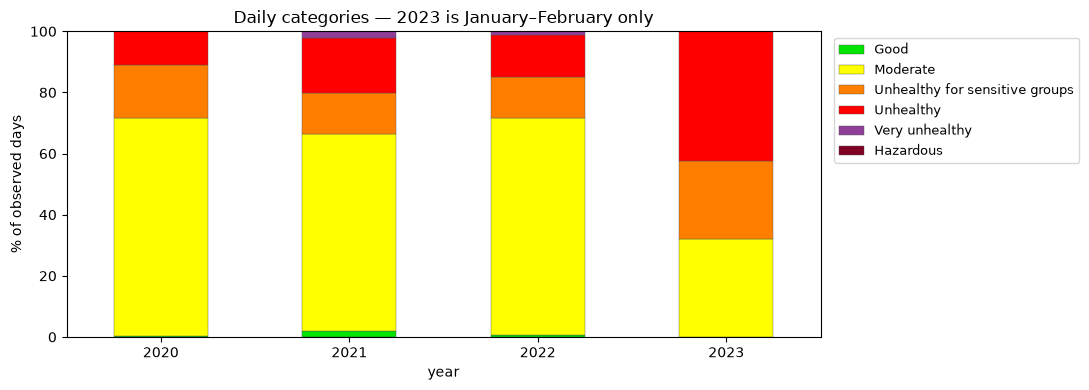

In [54]:
ax = category_percent.plot.bar(stacked=True, figsize=(11, 4), color=category_colors, rot=0, edgecolor="#555", linewidth=0.3)
ax.set_ylabel("% of observed days")
ax.set_title("Daily categories — 2023 is January–February only")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.savefig(output / "06_category_shares.png", dpi=140)
plt.show()

## 8. Seasonal patterns, missingness, and order of operations
We now move beyond a one-number-per-year summary. The important code is the grouping logic and its denominators; the plots make that logic inspectable.

### Summarize each year-month, then check its completeness

A monthly mean is a mean of available daily indices. `days_in_month` supplies the expected denominator. Show incomplete months rather than silently labelling them complete.

In [55]:
data["period"] = data["Date"].dt.to_period("M")
monthly = data.groupby("period").agg(
    observed_days=("aqi", "count"), mean_aqi=("aqi", "mean"),
    median_aqi=("aqi", "median"), pm25_mean=("PM2.5", "mean")
)
monthly["expected_days"] = monthly.index.days_in_month
monthly["coverage_pct"] = 100 * monthly["observed_days"] / monthly["expected_days"]
monthly["complete"] = monthly["observed_days"] == monthly["expected_days"]
monthly.loc[~monthly["complete"]]

,observed_days,mean_aqi,median_aqi,pm25_mean,expected_days,coverage_pct,complete
period,,,,,,,
2020-10,30,98.966667,92.5,34.207333,31,96.774194,False


### Create a year-by-month matrix

`unstack` turns the month level of the grouped index into columns. Reindexing creates missing entries for unobserved months; 2023 is not filled with zero.

In [56]:
matrix = data.groupby(["year", "month"])["aqi"].mean().unstack("month")
matrix = matrix.reindex(columns=range(1, 13))
matrix.round(1)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,119.5,136.0,82.8,66.9,72.3,70.5,84.8,76.9,79.6,99.0,111.6,133.5
2021,139.1,132.6,74.6,64.2,70.2,72.1,66.2,78.6,77.3,73.2,139.6,187.9
2022,154.9,133.0,108.9,78.9,75.7,81.6,67.0,70.7,75.6,82.3,70.2,152.1
2023,146.4,103.3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


### A heatmap exposes both seasonality and missing coverage

Grey means no observations, not good air. This is a continuous color scale for a monthly descriptive mean, not daily AQI category colors.

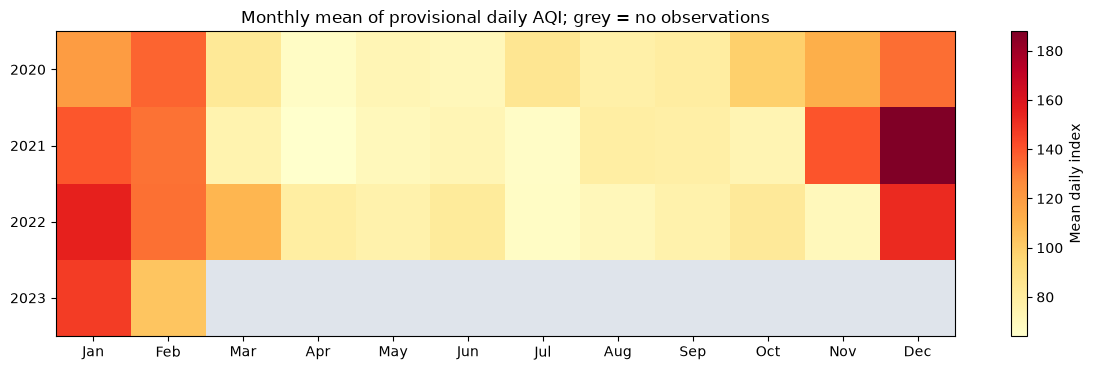

In [57]:
fig, ax = plt.subplots(figsize=(12, 3.8))
palette = plt.get_cmap("YlOrRd").copy()
palette.set_bad("#dfe4eb")
image = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto", cmap=palette)
ax.set_xticks(range(12), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks(range(len(matrix)), labels=matrix.index)
ax.set_title("Monthly mean of provisional daily AQI; grey = no observations")
fig.colorbar(image, ax=ax, label="Mean daily index")
plt.tight_layout()
plt.savefig(output / "07_monthly_heatmap.png", dpi=140)
plt.show()

### Compare the same month across the full-span years

Use 2020–2022; October 2020 remains one day short. An equal-year average gives each year one vote. A pooled daily mean weights years by their observed day counts. Neither choice should be hidden.

In [58]:
full_span = matrix.loc[[2020, 2021, 2022]]
seasonal = pd.DataFrame({
    "equal_year_mean": full_span.mean(axis=0),
    "between_year_sd": full_span.std(axis=0, ddof=1)
})
pooled = data.loc[data["year"] <= 2022].groupby("month")["aqi"].mean()
seasonal["pooled_daily_mean"] = pooled
seasonal.round(2)

,equal_year_mean,between_year_sd,pooled_daily_mean
month,,,
1,137.85,17.71,137.85
2,133.86,1.87,133.88
3,88.81,17.91,88.81
4,69.99,7.84,69.99
5,72.71,2.78,72.71
6,74.71,5.99,74.71
7,72.67,10.55,72.67
8,75.4,4.18,75.4
9,77.52,2.02,77.52


### Plot the seasonal profile with an honest error-bar label

The whisker is the sample standard deviation of three yearly monthly means. It is not a confidence interval and not the variation of all daily observations. Three years provide limited evidence about long-term climate or trends.

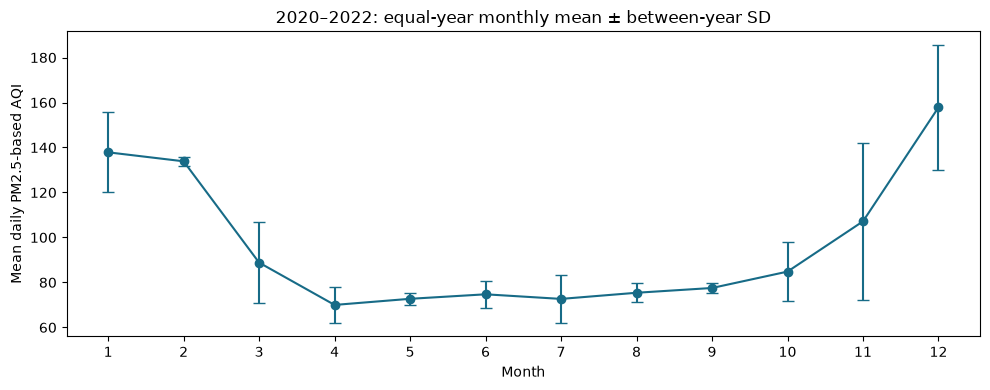

In [59]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(seasonal.index, seasonal["equal_year_mean"], yerr=seasonal["between_year_sd"], fmt="o-", capsize=4, color="#176b87")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily PM2.5-based AQI")
ax.set_title("2020–2022: equal-year monthly mean ± between-year SD")
plt.tight_layout()
plt.savefig(output / "08_seasonal_profile.png", dpi=140)
plt.show()

### Convert then average, or average then convert?
Because the rule has different slopes and rounding, generally
$$\operatorname{mean}(f(C_d))\ne f(\operatorname{mean}(C_d)).$$
The left side summarizes daily indices; the right converts a monthly mean concentration, which is not a daily AQI. We compute both to demonstrate why the order of operations must be documented, not to recommend reporting the second as an official index.

In [60]:
converted_monthly_means = []
for value in monthly["pm25_mean"]:
    converted_monthly_means.append(pm25_to_aqi(value, breakpoints))
monthly["index_of_mean_concentration"] = converted_monthly_means
monthly["order_difference"] = monthly["mean_aqi"] - monthly["index_of_mean_concentration"]
monthly[["mean_aqi", "index_of_mean_concentration", "order_difference"]].head(12).round(2)

,mean_aqi,index_of_mean_concentration,order_difference
period,,,
2020-01,119.55,122,-2.45
2020-02,136.0,152,-16.0
2020-03,82.84,82,0.84
2020-04,66.9,67,-0.1
2020-05,72.29,72,0.29
2020-06,70.47,70,0.47
2020-07,84.84,85,-0.16
2020-08,76.9,77,-0.1
2020-09,79.63,80,-0.37


### Sensitivity to the incomplete month

Compare October’s equal-year mean with and without the incomplete October 2020. This is a sensitivity check, not an imputation. It shows how one explicit inclusion decision affects the reported summary.

In [61]:
october_all = matrix.loc[[2020, 2021, 2022], 10].mean()
october_complete_only = matrix.loc[[2021, 2022], 10].mean()
print("October, three observed monthly means:", october_all)
print("October, two complete months:", october_complete_only)
print("Difference:", october_complete_only - october_all)

October, three observed monthly means: 84.80609318996416
October, two complete months: 77.7258064516129
Difference: -7.080286738351262


## 9. Turn the analysis into a dashboard
The dashboard is a small data product: it must show coverage and method, not only attractive plots. We use Plotly for hover, zoom, and a year selector. Python computes the results; JavaScript displays the exported figure in a browser.

[GitHub Pages](https://docs.github.com/en/pages/getting-started-with-github-pages/what-is-github-pages) hosts static HTML/CSS/JavaScript, not a Python server. Flask, Dash, or Streamlit would require another hosting service for their Python process. Our static export runs locally and on Pages without such a server.

We build the chart in Python, then insert it into a supplied presentation template. The HTML/CSS template is presentation scaffolding, not another language tutorial. No API key, live API request, or CDN is required to view the exported dashboard.

### First make one interactive chart

Plotly Express provides a compact entry point. In a configured notebook, `simple.show()` displays it. We save HTML so the browser route also works without a notebook renderer.

In [62]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

simple = px.line(data, x="Date", y="aqi", title="Provisional PM2.5-based AQI - observed records")
simple.write_html(output / "interactive_first_chart.html", include_plotlyjs=True)
print("Open outputs/interactive_first_chart.html in a browser")

Open outputs/interactive_first_chart.html in a browser


### Prepare dashboard data on a complete calendar

The main dashboard uses calendar-aligned data so the missing day remains visible. Both missing calendar days and unobserved future months must remain missing. Rolling means still require all seven readings.

In [63]:
dashboard_daily = data.set_index("Date").reindex(calendar)
dashboard_daily["aqi"] = dashboard_daily["aqi"].astype(float)
dashboard_daily["rolling_aqi"] = dashboard_daily["aqi"].rolling(7, min_periods=7).mean()
dashboard_daily["year"] = dashboard_daily.index.year
years = [2020, 2021, 2022, 2023]
default_year = 2022
dashboard = make_subplots(
    rows=2, cols=2, specs=[[{"colspan": 2}, None], [{}, {}]],
    subplot_titles=["Daily index and seven-day mean", "Monthly mean of daily index", "Observed days by category"],
    row_heights=[0.60, 0.40], vertical_spacing=0.18
)

### Add four traces per year
A **trace** is one plotted series. Each year contributes daily AQI, its rolling mean, monthly means, and category counts. The loop changes the selected year, not the calculation rule. Read one iteration before considering all four.

`visible` chooses the initial year. Hover text exposes values; the category chart labels counts, so color is not the only encoding. Missing months break the monthly line.

In [64]:
for year in years:
    view = dashboard_daily.loc[dashboard_daily["year"] == year]
    visible = year == default_year
    dashboard.add_trace(go.Scatter(
        x=view.index, y=view["aqi"], name="Daily AQI", mode="lines",
        line={"color": "#75aabd", "width": 1}, visible=visible
    ), row=1, col=1)
    dashboard.add_trace(go.Scatter(
        x=view.index, y=view["rolling_aqi"], name="7-day mean", mode="lines",
        line={"color": "#174a63", "width": 2.5}, visible=visible
    ), row=1, col=1)
    dashboard.add_trace(go.Scatter(
        x=list(range(1, 13)), y=matrix.loc[year].to_numpy(dtype=float),
        name="Monthly mean", mode="lines+markers",
        line={"color": "#176b87"}, visible=visible
    ), row=2, col=1)
    counts = category_counts.loc[year].tolist()
    dashboard.add_trace(go.Bar(
        x=["Good", "Moderate", "Sensitive", "Unhealthy", "Very unhealthy", "Hazardous"],
        y=counts, text=counts, textposition="outside", marker_color=category_colors,
        marker_line={"color": "#475569", "width": 0.5},
        name="Category days", visible=visible
    ), row=2, col=2)

### A dropdown changes the visible traces and coverage title

There are sixteen traces: four per year. The visibility mask has one Boolean per trace. The title changes alongside the chart, so selecting 2023 cannot hide its partial coverage.

In [65]:
buttons = []
for position, year in enumerate(years):
    visibility = [False] * len(dashboard.data)
    visibility[position * 4:position * 4 + 4] = [True] * 4
    days = int(annual.loc[year, "observed_days"])
    note = "January–February only" if year == 2023 else "full-year span"
    title = f"{year} · {days} observed days<br><sup>{note}</sup>"
    buttons.append({"label": str(year), "method": "update", "args": [{"visible": visibility}, {"title.text": title}]})
dashboard.update_layout(updatemenus=[{"buttons": buttons, "active": 2, "x": 1, "y": 1.16, "xanchor": "right"}])

### Label scales, maintain legibility, and show the reference line

A consistent daily-index axis makes year changes comparable. The line at 100 is an index-category boundary. Monthly chart points remain descriptive averages; category counts apply to daily values only.

In [66]:
dashboard.update_layout(
    title="2022 · 365 observed days<br><sup>full-year span</sup>",
    height=830, template="plotly_white", font={"family": "Arial", "size": 14},
    margin={"l": 65, "r": 30, "t": 125, "b": 90},
    legend={"orientation": "h", "y": -0.15}
)
dashboard.update_yaxes(title_text="PM2.5-based AQI", range=[0, 320], row=1, col=1)
dashboard.update_yaxes(title_text="Mean daily index", range=[0, 220], row=2, col=1)
dashboard.update_yaxes(title_text="Observed days", range=[0, 300], row=2, col=2)
dashboard.update_xaxes(tickmode="array", tickvals=list(range(1, 13)), ticktext=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"], row=2, col=1)
dashboard.add_hline(y=100, line_dash="dot", line_color="#64748b", row=1, col=1)
dashboard.update_xaxes(rangeslider_visible=False, row=1, col=1)

### Export a self-contained static site folder

The provided template holds the page layout and method notes. The local Plotly JavaScript bundle keeps viewing independent of an Internet connection. All files inside `docs` must travel together.

In [67]:
from plotly.offline import get_plotlyjs

site = project / "docs"
site.mkdir(exist_ok=True)
(site / "plotly.min.js").write_text(get_plotlyjs(), encoding="utf-8")
chart_html = dashboard.to_html(full_html=False, include_plotlyjs=False, div_id="aqi-dashboard", config={"responsive": True, "displaylogo": False})
template = (project / "dashboard" / "template.html").read_text(encoding="utf-8")
page = template.replace("{{CHART}}", chart_html)
display_summary = annual[["observed_days", "mean_aqi", "pct_observed_above_100", "coverage_pct"]].copy()
display_summary.columns = ["Observed days", "Mean daily index", "Days >100 (%)", "Year coverage (%)"]
page = page.replace("{{ANNUAL_TABLE}}", display_summary.round(2).to_html(classes="summary", border=0))
(site / "index.html").write_text(page, encoding="utf-8")
(site / ".nojekyll").write_text("", encoding="utf-8")
print("Dashboard:", site / "index.html")

Dashboard: ./docs/index.html


## 10. Preserve the source-to-dashboard chain
The output is not just an image. Preserve clean daily data, audit tables, rule tables, package versions, source hashes, and instructions. A hash identifies file bytes; it does not establish that a measurement is true. A saved notebook output does not prove the current code runs: restart/run-all and rebuild the site.

To publish your own copy, push the repository and enable GitHub Pages on the exported `docs` folder. The published lecture dashboard is at https://drfarrukh.github.io/teaching/courses/tools-and-tech-in-data-science/lectures/lecture-02/dashboard/.

### Export the analysis and its audit trail

Use explicit filenames and `index=False` where the index is not a meaningful column. Save period-indexed tables with their period labels. The dashboard download is the same derived table used for analysis.

In [68]:
data.to_csv(output / "daily_aqi.csv", index=False)
data.to_csv(site / "daily_aqi.csv", index=False)
annual.to_csv(output / "annual_summary.csv")
monthly.to_csv(output / "monthly_summary.csv")
matched_summary.to_csv(output / "matched_jan_feb.csv")
coverage.to_csv(output / "coverage.csv")
blank_audit.to_csv(output / "blank_row_audit.csv", index=False)
breakpoints.to_csv(output / "breakpoints_2024.csv", index=False)
legacy_breakpoints.to_csv(output / "breakpoints_legacy.csv", index=False)
pd.Series(missing_dates, name="missing_date").to_csv(output / "missing_dates.csv", index=False)

### Record inputs, configuration, and software versions

This manifest is generated from the actual local files and environment. Its policy fields prevent a future rerun from silently switching standards or denominators.

In [69]:
import hashlib
import json
import platform
import matplotlib
import plotly

input_hashes = {}
for file in sorted(raw_folder.glob("*.csv")):
    input_hashes[file.name] = hashlib.sha256(file.read_bytes()).hexdigest()
manifest = {
    "aqi_scheme": scheme, "concentration_rule": "truncate to 0.1 using Decimal",
    "index_rounding": "nearest integer, half-up", "unsupported": "missing or invalid inputs and above-table values return missing",
    "annual_denominator": "observed valid days", "matched_window": "Jan 1 to Feb 28 inclusive",
    "input_sha256": input_hashes, "python": platform.python_version(),
    "packages": {"numpy": np.__version__, "pandas": pd.__version__, "matplotlib": matplotlib.__version__, "plotly": plotly.__version__}
}
(output / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
(site / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Saved data, checks, rule tables, manifest, and dashboard")

Saved data, checks, rule tables, manifest, and dashboard


- The conversion matches explicit boundary cases and uses a named, fixed rule.
- Missing calendar coverage and partial-year data remain visible.
- Year comparisons state their periods and denominators.
- The dashboard is generated from the same derived data and can be rebuilt.


**Next lecture:** relational modelling and SQL. Separate observation, station, and source tables will let us ask how a join can duplicate daily values and distort this analysis.